# DS Lab 2: Data Wrangling II
Based on Academic Performance Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Creating sample dataset
np.random.seed(42)  # ensures reproducible practical output
data = {
    'math_score': np.random.randint(55, 90, 30),
    'reading_score': np.random.randint(60, 100, 30),
    'writing_score': np.random.randint(55, 90, 30),
    'placement_score': np.random.randint(70, 105, 30),
    'club_join_year': np.random.randint(2018, 2022, 30)
}

df = pd.DataFrame(data)
df.head()

,math_score,reading_score,writing_score,placement_score,club_join_year
0,83,63,77,102,2020
1,69,84,75,92,2020
2,62,73,70,93,2020
3,75,68,72,104,2019
4,73,85,78,91,2021


In [3]:
# Introduce missing values
df.loc[5, 'math_score'] = np.nan
df.loc[10, 'reading_score'] = np.nan
df.loc[15, 'writing_score'] = np.nan

df.iloc[25]

math_score           57.0
reading_score        73.0
writing_score        61.0
placement_score      92.0
club_join_year     2020.0
Name: 25, dtype: float64

In [4]:
# Check missing values
df.isnull()

,math_score,reading_score,writing_score,placement_score,club_join_year
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,True,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [5]:
# Fill missing values with mean (avoids chained-assignment warnings)
df['math_score'] = df['math_score'].fillna(df['math_score'].mean())
df['reading_score'] = df['reading_score'].fillna(df['reading_score'].mean())
df['writing_score'] = df['writing_score'].fillna(df['writing_score'].mean())

df.head(20)

,math_score,reading_score,writing_score,placement_score,club_join_year
0,83.000000,63.000000,77.000000,102,2020
1,69.000000,84.000000,75.000000,92,2020
2,62.000000,73.000000,70.000000,93,2020
3,75.000000,68.000000,72.000000,104,2019
4,73.000000,85.000000,78.000000,91,2021
5,71.310345,61.000000,80.000000,96,2019
6,65.000000,79.000000,79.000000,104,2019
7,65.000000,87.000000,83.000000,70,2018
8,78.000000,66.000000,69.000000,104,2019
9,78.000000,67.000000,55.000000,83,2018


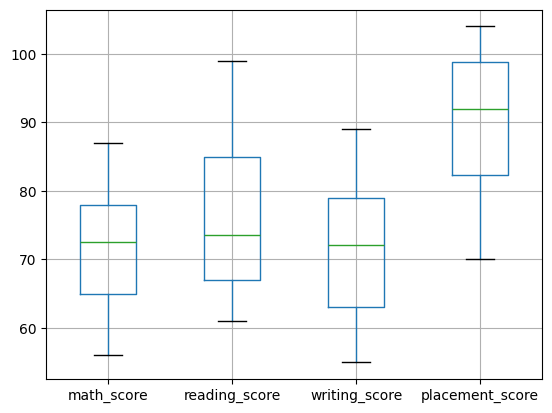

In [6]:
# Detect outliers using boxplot
df.boxplot(['math_score','reading_score','writing_score','placement_score'])
plt.show()

In [7]:
# Z-score method
z = np.abs(stats.zscore(df[['math_score','reading_score','writing_score']]))
outliers = np.where(z > 3)
outliers

(array([], dtype=int64), array([], dtype=int64))

In [8]:
# IQR method
Q1 = df['reading_score'].quantile(0.25)
Q3 = df['reading_score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['reading_score'] < lower) | (df['reading_score'] > upper)]
outliers

,math_score,reading_score,writing_score,placement_score,club_join_year


In [9]:
# Replace outliers with median
median = df['reading_score'].median()
df['reading_score'] = np.where(
    (df['reading_score'] < lower) | (df['reading_score'] > upper),
    median,
    df['reading_score']
)

df.head(20)

,math_score,reading_score,writing_score,placement_score,club_join_year
0,83.000000,63.000000,77.000000,102,2020
1,69.000000,84.000000,75.000000,92,2020
2,62.000000,73.000000,70.000000,93,2020
3,75.000000,68.000000,72.000000,104,2019
4,73.000000,85.000000,78.000000,91,2021
5,71.310345,61.000000,80.000000,96,2019
6,65.000000,79.000000,79.000000,104,2019
7,65.000000,87.000000,83.000000,70,2018
8,78.000000,66.000000,69.000000,104,2019
9,78.000000,67.000000,55.000000,83,2018


In [10]:
# Transform club_join_year to duration
current_year = 2026
df['duration'] = current_year - df['club_join_year']

df.head(20)

,math_score,reading_score,writing_score,placement_score,club_join_year,duration
0,83.000000,63.000000,77.000000,102,2020,6
1,69.000000,84.000000,75.000000,92,2020,6
2,62.000000,73.000000,70.000000,93,2020,6
3,75.000000,68.000000,72.000000,104,2019,7
4,73.000000,85.000000,78.000000,91,2021,5
5,71.310345,61.000000,80.000000,96,2019,7
6,65.000000,79.000000,79.000000,104,2019,7
7,65.000000,87.000000,83.000000,70,2018,8
8,78.000000,66.000000,69.000000,104,2019,7
9,78.000000,67.000000,55.000000,83,2018,8


In [11]:
# Log transformation to reduce skewness
df['log_math'] = np.log10(df['math_score'])

df[['math_score','log_math']].head()

,math_score,log_math
0,83.0,1.919078
1,69.0,1.838849
2,62.0,1.792392
3,75.0,1.875061
4,73.0,1.863323


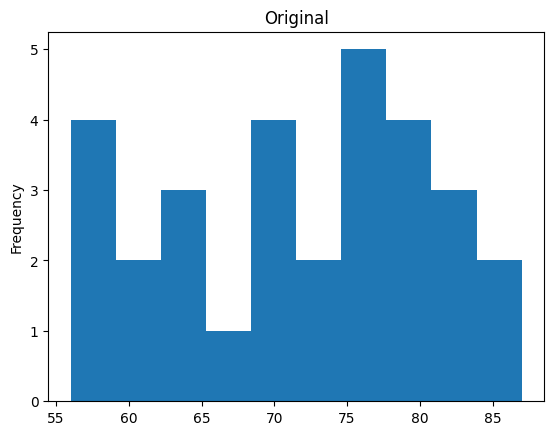

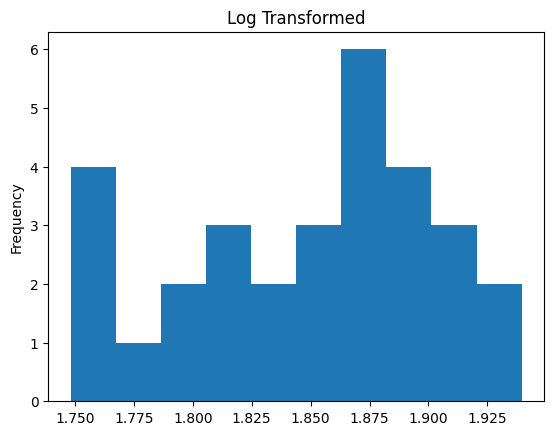

In [12]:
# Histogram comparison
df['math_score'].plot(kind='hist', title='Original')
plt.show()

df['log_math'].plot(kind='hist', title='Log Transformed')
plt.show()